In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from flexcraft.data.data import DesignData
from flexcraft.files import PDBFile
from flexcraft.pipelines.tcr.utils import *
from flexcraft.sequence.aa_codes import AF2_CODE, decode, PMPNN_CODE
import anarci
from Bio import Align
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import tempfile
from flexcraft.pipelines.tcr.tcrdock import *


In [2]:
tmp = tempfile.TemporaryDirectory(prefix="geometry_devel_")
tmpdir = Path(tmp.name)

In [3]:
def _data_to_pos(x):
    if hasattr(x, "to_data"):
        x = x.to_data()
        assert isinstance(x, DesignData)
    if isinstance(x, DesignData):
        x = x["atom_positions"]
    return x
def order_chains(design:DesignData, order:np.ndarray):
    parts = []
    for chain in order:
        parts.append(design["chain_index"]==chain)
    return DesignData.concatenate([design[part] for part in parts], sep_chains=False)

def convert_chains(input_design:DesignData, d:dict|None=None):
    if d is None:
        d = {}
        for x,y in zip(np.sort(np.unique(input_design["chain_index"])), range(len(np.unique(input_design["chain_index"])))):
            d[int(x)]=int(y)
    print(d)
    design = input_design.update(chain_index=np.array([d[int(x)] for x in input_design["chain_index"]]))
    return design, d

def align(x:DesignData, y:DesignData, on_chain:str|int|list[str|int]):
    
    # convert chains to concrete integer range
    y,d = convert_chains(y)
    x,_ = convert_chains(x, d=d)

    on_chain=d[on_chain]

    # bring chains of x in same order
    y_chain_order = np.unique(y["chain_index"])
    x = order_chains(x, y_chain_order)

    # get chain mask
    on_chain = np.array(list(on_chain))
    chain_mask_x = (x["chain_index"][:,None]==on_chain[None,:]).any(axis=1)
    chain_mask_y = (y["chain_index"][:,None]==on_chain[None,:]).any(axis=1)

    # convert to 3d coordinates
    x = _data_to_pos(x)
    y = _data_to_pos(y)

    #

    return x

In [4]:
cdr_coords = imgt_mapper.copy()
params = {
    "imgt_mapper":imgt_mapper,
    "cdr_coords":cdr_coords,
    "tcr_chain_index":np.array([0,1]),
    "mhc_chain_index":np.array([2]),
    "pdb_id":"",
    "mhc_class":1
}
def number_anarci(
    input_design:DesignData,
    params:dict,
    chains:List[int]=[],
    code:str=AF2_CODE,
    scheme:str="imgt",
    trim:bool=True,
    classify_all:bool = False
    )->DesignData:
    
    if not chains:
        classify_all=True
        chains = np.unique(input_design["chain_index"])

    for chain in chains:
        chain_mask = np.array(input_design["chain_index"]) == chain
        # Pass only this chain's sequence to anarci
        chain_aa = np.array(input_design["aa"])[chain_mask]
        seq = decode(chain_aa, code=code)
        numbering = anarci.number(sequence=seq, scheme=scheme)
        if numbering[0]:
            chain_type = numbering[-1]
            if chain_type in ["A", "L"]:
                print(f"Setting chain {chain} to {chain_type}!")
                params["tcr_chain_index"][0] = chain
            elif chain_type in ["B", "H"]:
                print(f"Setting chain {chain} to {chain_type}!")
                params["tcr_chain_index"][1] = chain
            else:
                print(f"Unknown chain type {chain_type} of chain {chain}!")
                continue
            # Build IMGT position strings (e.g. "1", "111", "111A") then convert to int
            numbering = [f"{x[0][0]}{x[0][1].strip()}" for x in numbering[0] if x[1] != "-"]
            numbering = [int(x) if x.isnumeric() else int(x[:-1]) for x in numbering]

            residue_index = np.array(input_design["residue_index"])
            if len(residue_index[chain_mask])>len(numbering):
                # extend variable region by constant region
                if trim:
                    print(f"Trimming chain {chain} to length {len(numbering)}.")
                    index = np.arange(len(residue_index))[chain_mask]
                    start = index[0]
                    stop = index[-1]+1
                    mask = np.ones(len(residue_index), dtype=np.bool_)
                    mask[start+len(numbering):stop] = False
                    input_design = input_design[mask]
                    chain_mask = np.array(input_design["chain_index"]) == chain
                    residue_index = np.array(input_design["residue_index"])
                else:
                    numbering += np.arange(numbering[-1]+1,numbering[-1]+1+chain_mask.sum()-len(numbering)).tolist()
            residue_index[chain_mask] = numbering
            input_design = input_design.update(residue_index=np.array(residue_index))

            # update cdr coords dict
            pre = ["a","b",][chain_type=="B"or chain_type=="H"]
            chain_mask = np.array(input_design["chain_index"]) == chain
            for k in params["imgt_mapper"].keys():
                if k.startswith(pre):
                    index = np.arange(chain_mask.sum())
                    mask = (input_design["residue_index"][chain_mask][:, None]==np.arange(*params["imgt_mapper"][k])[None,:]).any(axis=1)
                    params["cdr_coords"][k] = (int(index[mask][0]), int(index[mask][-1]+1))
            
        else:
            print(f"No numbering found for chain {chain}!")
    # check if chain indices correct
    if params["tcr_chain_index"][0]==params["tcr_chain_index"][1]:
        raise ValueError("TCR chains identical! Currently only 2 chain tcrs supported.")
    if (params["mhc_chain_index"][:,None] == params["tcr_chain_index"][None,:]).any() or classify_all:
        # fix mhc chain index to longest non-tcr chain
        chains = np.unique(input_design["chain_index"])
        # mask out tcr chains
        tcr_mask = ~(chains[:,None]==params["tcr_chain_index"][None,:]).any(axis=1)
        chains = chains[tcr_mask]
        # get chain lengths
        chain_lengths =  (input_design["chain_index"][:,None] == chains[None,:]).sum(axis=0)
        # take the n longest chain indices, where n the number of non-tcr chains -1 (for the peptide chain) 
        # take all non-tcr-chains except for smalles (peptide, hopefully)
        if params["mhc_class"] == 1:
            params["mhc_chain_index"] = np.array(
                [chains[r]
                for r in np.argsort(chain_lengths)[:-(len(chains)-1):-1]],dtype=int
            )
        elif params["mhc_class"]==2:
            params["mhc_chain_index"] = np.array(
                [chains[r]
                for r in np.argsort(chain_lengths)[:-len(chains):-1]],dtype=int
            )
        print(f"Classified chains {params['mhc_chain_index']} as MHC/antigen chains")
    return input_design, params

In [5]:
test_id = "9PBH"
params_1 = params.copy()
params_1["pdb_id"]=test_id
test_file = download_structure(test_id, out_dir=tmpdir.__str__())
test_file = clean_chothia(test_file)
mhc1_design = PDBFile(path=test_file).to_data()
mhc1_design,d = convert_chains(mhc1_design)

ERROR:2026-05-08 17:48:06,401:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/ntbiotech/.miniforge/envs/flexcraft_2/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/ntbiotech/.miniforge/envs/flexcraft_2/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/ntbiotech/.miniforge/envs/flexcraft_2/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [6]:
mhc1_design, params_1 = number_anarci(mhc1_design, params=params_1)

No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Trimming chain 3 to length 116.
Setting chain 4 to B!
Trimming chain 4 to length 114.
Classified chains [0] as MHC/antigen chains


In [7]:
positions_1 = get_mhc1_positions(mhc1_design, params_1)

In [8]:
test_id = "8VD2"
params_2 = params.copy()
params_2.update(pdb_id=test_id, mhc_class=2)
mhc2_design_path = clean_chothia(download_structure(test_id,out_dir=tmpdir.__str__()))

mhc2_design = PDBFile(path=mhc2_design_path).to_data()
mhc2_design, d = convert_chains(mhc2_design)
mhc2_design, params_2 = number_anarci(mhc2_design, params=params_2)


{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
No numbering found for chain 0!
No numbering found for chain 1!
No numbering found for chain 2!
Setting chain 3 to A!
Trimming chain 3 to length 111.
Setting chain 4 to B!
Trimming chain 4 to length 110.
Classified chains [0 1] as MHC/antigen chains


In [9]:
from shutil import ExecError
import sys
import os
query = mhc2_design[mhc2_design["chain_index"] == params["mhc_chain_index"][0]]
query = SeqRecord(Seq(decode(np.array(query["aa"]), AF2_CODE)), id=params["pdb_id"], name="mhc 2")
# blast:
# download exe
if sys.platform == 'linux':
    address = ('https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/latest/ncbi-blast-2.17.0+-x64-linux.tar.gz')
elif sys.platform == 'darwin':
    address = ('https://ftp.ncbi.nlm.nih.gov/blast/executables/blast+/latest/ncbi-blast-2.17.0+-x64-macosx.tar.gz')
else:
    print('unrecognized platform type:', sys.platform,'expected "linux" or "darwin"')
    exit()

positions_2 = get_mhc2_positions(
    design=mhc2_design,
    params=params_2,
    db_files={
        "A":Path("/home/ntbiotech/Documents/Current_projects/BinderDesign/TCRdock/tcrdock/db/both_class_2_A_chains_v2.fasta"),
        "B":Path("/home/ntbiotech/Documents/Current_projects/BinderDesign/TCRdock/tcrdock/db/both_class_2_B_chains_v2.fasta")
    },
    blast_exe=Path("../../../ncbi-blast-2.17.0+/bin"),
    )


(array([ 1.71409900e-16, -1.58898053e-16,  1.00000000e+00]),
 array([ 2.00000000e+00,  2.00000000e+00, -2.50236942e-17]),
 array([ 2.00000000e+00, -2.00000000e+00, -6.60615907e-16]))

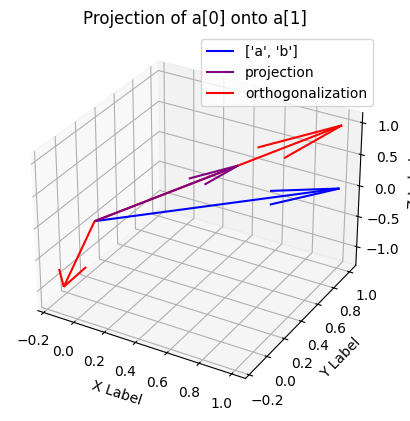

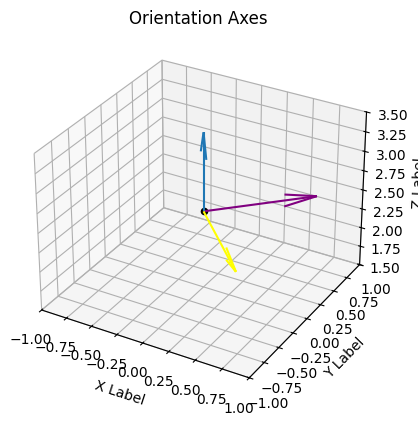

In [10]:
a = np.concatenate([np.full((6,2),1),np.arange(0,6)[:,None]], axis=-1)
b = np.concatenate([np.full((6,2),-1),np.arange(0,6)[:,None]], axis=-1)
fig = plt.figure()
ax = fig.add_subplot(projection='3d', )
ax.scatter(*a[:2].T, c="black", alpha=0)
ax.quiver(0,0,0, *a[:2].T, pivot="tail", label=["a", "b"], color=["blue", "red"])
ax.quiver(0,0,0, *proj(a[0],a[1]) , pivot="tail", color="purple", normalize=True, label="projection")
ax.quiver(0,0,0, *orthogonalize(*a[:2]) , pivot="tail", color="red", normalize=True, label="orthogonalization")
ax.scatter(*orthogonalize(*a[:2]), alpha=0)


ax.legend()
ax.set_title("Projection of a[0] onto a[1]")
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
fig = plot_axes(a,b)
get_axes(a,b)

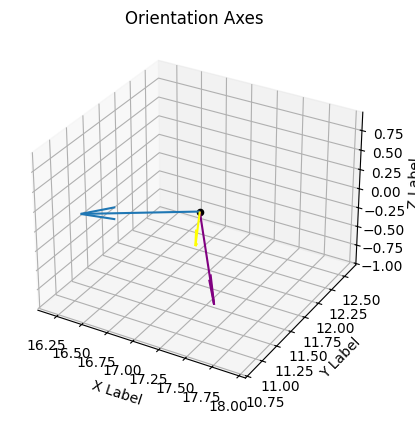

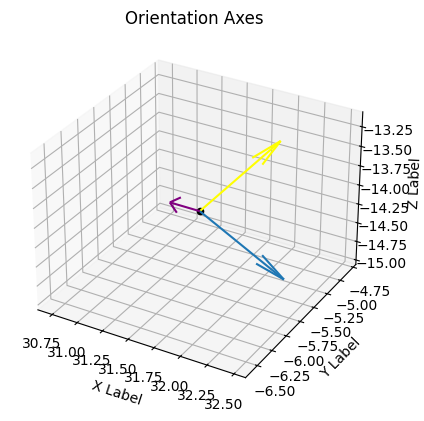

In [11]:
fig1 = plot_axes(
    get_mhc_coords(mhc1_design, positions_1)[:6],
    get_mhc_coords(mhc1_design, positions_1)[6:]
)
fig2 = plot_axes(
    get_mhc_coords(mhc2_design, positions_2[0], atoms=["CA"]),
    get_mhc_coords(mhc2_design, positions_2[1], atoms=["CA"])
)

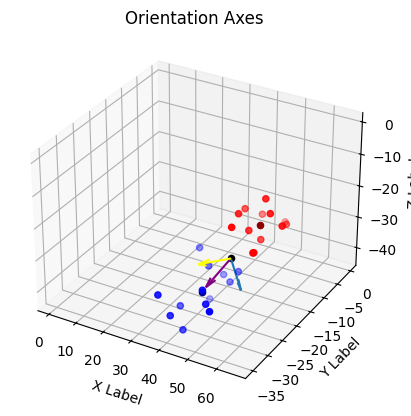

In [ ]:
fig = plot_axes(
    get_tcr_coords(mhc2_design, params_2["tcr_chain_index"])[:13],
    get_tcr_coords(mhc2_design, params_2["tcr_chain_index"])[13:],
    plot_points=True,
    normalize=10,
    angle=None
    )

In [13]:
tmp.cleanup()